# 12 — Motor de decisión (OE3)

Traduce un pronóstico con bandas de incertidumbre (`fecha_hora, real, q10, q50, q90`) en una señal
de **comprar/vender/esperar**, distinta según el rol del usuario (generador vs. comercializador),
sobre los dos horizontes prometidos (24h y 72h).

**Qué modelo alimenta cada horizonte se decide en un solo lugar**:
`data/processed/resultados/fuentes_pronostico.json`, leído por `cargar_fuente_pronostico()` en
`src/motor_decision.py`. Este notebook NO tiene rutas de archivo hardcodeadas -- si cambia el modelo
de un horizonte, se edita el JSON y se re-corre este notebook, sin tocar código. Ver
`docs/motor_decision_guia.md` para el procedimiento de cómo agregar o reemplazar un modelo.

**Fuentes actuales** (ambas N-BEATSx + calibración conforme adaptativa, las dos son "contrato final"):

| Horizonte | Modelo | Archivo | Cobertura |
|---|---|---|---|
| 24h | N-BEATSx + CQR adaptativo | `pronostico_con_bandas_2026_adaptativo.csv` | ~78% |
| 72h | N-BEATSx (h=72, MQLoss) + CQR adaptativo por tramo | `pronostico_con_bandas_72h_2026_adaptativo.csv` | ~78% |

> Nota histórica: la primera versión de este notebook generaba las bandas de 72h con regresión por
> cuantiles de XGBoost como *fallback*, porque N-BEATSx todavía no tenía pipeline a 72h. Ese pipeline
> se construyó en el commit `3d8d685` (ver bitácora 2026-09-10), así que el fallback se eliminó y
> `fuentes_pronostico.json` ahora apunta a la versión calibrada de N-BEATSx. Cambiar la fuente fue
> editar 5 campos del JSON -- exactamente el flujo que documenta la guía.

La lógica del motor vive en `src/motor_decision.py` (reusable, no depende de notebooks): 3 métodos
de umbral (percentiles fijos, percentiles rodantes causales, y percentiles fijos + filtro de
confianza por ancho de banda), evaluados con un backtest económico simple antes de elegir uno.

In [1]:
# --- Celda de arranque ---
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

from motor_decision import (
    comparar_metodos, elegir_mejor_metodo, generar_senales, evaluar_backtest,
    cargar_fuente_pronostico,
)

print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: C:\Users\rafad\Downloads\Proyecto_Final\xm-spot-price-predictor


## 1. Cargar las fuentes de pronóstico (24h y 72h)

Las dos vienen de `fuentes_pronostico.json` vía `cargar_fuente_pronostico()`, que además valida el
contrato de columnas (`validar_contrato_pronostico`: columnas obligatorias, NaN en cuantiles = error;
cuantiles cruzados = advertencia no bloqueante). El archivo de 72h trae columnas extra (`cutoff`,
`paso_horas`, `margen`) que el loader ignora -- se queda solo con `fecha_hora, real, q10, q50, q90`.

In [2]:
bandas = {}
for horizonte in ["24h", "72h"]:
    df, meta = cargar_fuente_pronostico(RAIZ, horizonte)
    bandas[horizonte] = df
    cob = ((df["real"] >= df["q10"]) & (df["real"] <= df["q90"])).mean()
    print(f"{horizonte}: {meta['modelo']}")
    print(f"     calibrado={meta['calibrado']} | filas={len(df)} | cobertura [q10,q90]={cob*100:.1f}%\n")

bandas["24h"].head()

[validar_contrato_pronostico] advertencia: C:\Users\rafad\Downloads\Proyecto_Final\xm-spot-price-predictor\data\processed\resultados\pronostico_con_bandas_2026_adaptativo.csv tiene 2 fila(s) con cuantiles cruzados (q10>q50 o q50>q90) de 5208 totales -- revisar si crece en un modelo nuevo, probablemente borde de calibración.
24h: N-BEATSx + calibracion conforme adaptativa (CQR, ventana movil 30 dias)
     calibrado=True | filas=5208 | cobertura [q10,q90]=78.0%

72h: N-BEATSx (h=72, MQLoss con festivos) + calibracion conforme adaptativa por tramo de horizonte
     calibrado=True | filas=5184 | cobertura [q10,q90]=78.1%



,fecha_hora,real,q10,q50,q90
0,2026-01-01 00:00:00,327.90985,255.30502,268.59305,273.73154
1,2026-01-01 01:00:00,307.90985,236.00491,265.54776,276.69620
2,2026-01-01 02:00:00,296.32185,211.90027,254.50874,269.91086
3,2026-01-01 03:00:00,296.32185,196.14671,246.64644,263.05940
4,2026-01-01 04:00:00,296.32185,191.18434,246.62206,259.15762


## 2. Comparar los 3 métodos de umbral, por rol y por horizonte

Backtest económico simple (`evaluar_backtest` en `src/motor_decision.py`): compara el precio real
promedio en las horas donde el motor dice actuar contra el precio real promedio general. Se marca
como "válido" el método cuya frecuencia de acción cae en un rango razonable (10%-40% de las horas)
-- una regla que casi nunca dispara no es útil aunque su ventaja promedio se vea bien.

In [3]:
# El histórico 2019-2025 alimenta los percentiles de los métodos "fijo" y "banda"
precio_historico_train = pd.read_csv(
    RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv", usecols=["precio_bolsa"]
)["precio_bolsa"].values

resultados_comparacion = {}
for horizonte in ["24h", "72h"]:
    for rol in ["generador", "comercializador"]:
        tabla = comparar_metodos(bandas[horizonte], rol, precio_historico_train)
        resultados_comparacion[(horizonte, rol)] = tabla
        print(f"=== {horizonte} -- {rol} ===")
        print(tabla.to_string(index=False))
        print()

=== 24h -- generador ===
 metodo  ventaja_cop_kwh  frecuencia_accion  horas_accion  valido
  banda       345.643785           0.168971           880    True
   fijo       313.341899           0.375576          1956    True
rodante       244.079666           0.293587          1529    True

=== 24h -- comercializador ===
 metodo  ventaja_cop_kwh  frecuencia_accion  horas_accion  valido
  banda       281.628931           0.143433           747    True
   fijo       281.424182           0.144009           750    True
rodante       169.576971           0.145929           760    True

=== 72h -- generador ===
 metodo  ventaja_cop_kwh  frecuencia_accion  horas_accion  valido
  banda       299.731818           0.195216          1012    True
   fijo       278.551838           0.410301          2127   False
rodante       203.909651           0.308449          1599    True

=== 72h -- comercializador ===
 metodo  ventaja_cop_kwh  frecuencia_accion  horas_accion  valido
  banda       279.465920   

In [4]:
# --- Elegir el método ganador por (horizonte, rol) ---
ganadores = {}
for clave, tabla in resultados_comparacion.items():
    metodo, es_valido = elegir_mejor_metodo(tabla)
    ganadores[clave] = metodo
    horizonte, rol = clave
    nota = "" if es_valido else "  (ningún método quedó en el rango de frecuencia válido -- se eligió el de mayor ventaja igual)"
    print(f"{horizonte:4s} | {rol:15s} -> método ganador: {metodo}{nota}")

24h  | generador       -> método ganador: banda
24h  | comercializador -> método ganador: banda
72h  | generador       -> método ganador: banda
72h  | comercializador -> método ganador: banda


## 3. Generar señales finales con el método ganador y guardarlas

In [5]:
señales_finales = []
for (horizonte, rol), metodo in ganadores.items():
    df_bandas = bandas[horizonte]
    senal = generar_senales(df_bandas, metodo, rol, precio_historico_train)
    df_salida = df_bandas[["fecha_hora", "real", "q10", "q50", "q90"]].copy()
    df_salida["horizonte"] = horizonte
    df_salida["rol"] = rol
    df_salida["metodo"] = metodo
    df_salida["senal"] = senal.values
    señales_finales.append(df_salida)

señales_finales = pd.concat(señales_finales, ignore_index=True)
señales_finales.to_csv(RAIZ / "data" / "processed" / "resultados" / "senales_motor_decision_2026.csv", index=False)

print(f"Guardado: data/processed/resultados/senales_motor_decision_2026.csv ({len(señales_finales)} filas)")
señales_finales.groupby(["horizonte", "rol", "senal"]).size().unstack(fill_value=0)

Guardado: data/processed/resultados/senales_motor_decision_2026.csv (20784 filas)


senal                      comprar  esperar  evitar_compra  retener  vender
horizonte rol                                                              
24h       comercializador      747     3581            880        0       0
          generador              0     3581              0      747     880
72h       comercializador      613     3559           1012        0       0
          generador              0     3559              0      613    1012

## 4. Ejemplo visual: últimas 2 semanas de 2026, horizonte 24h

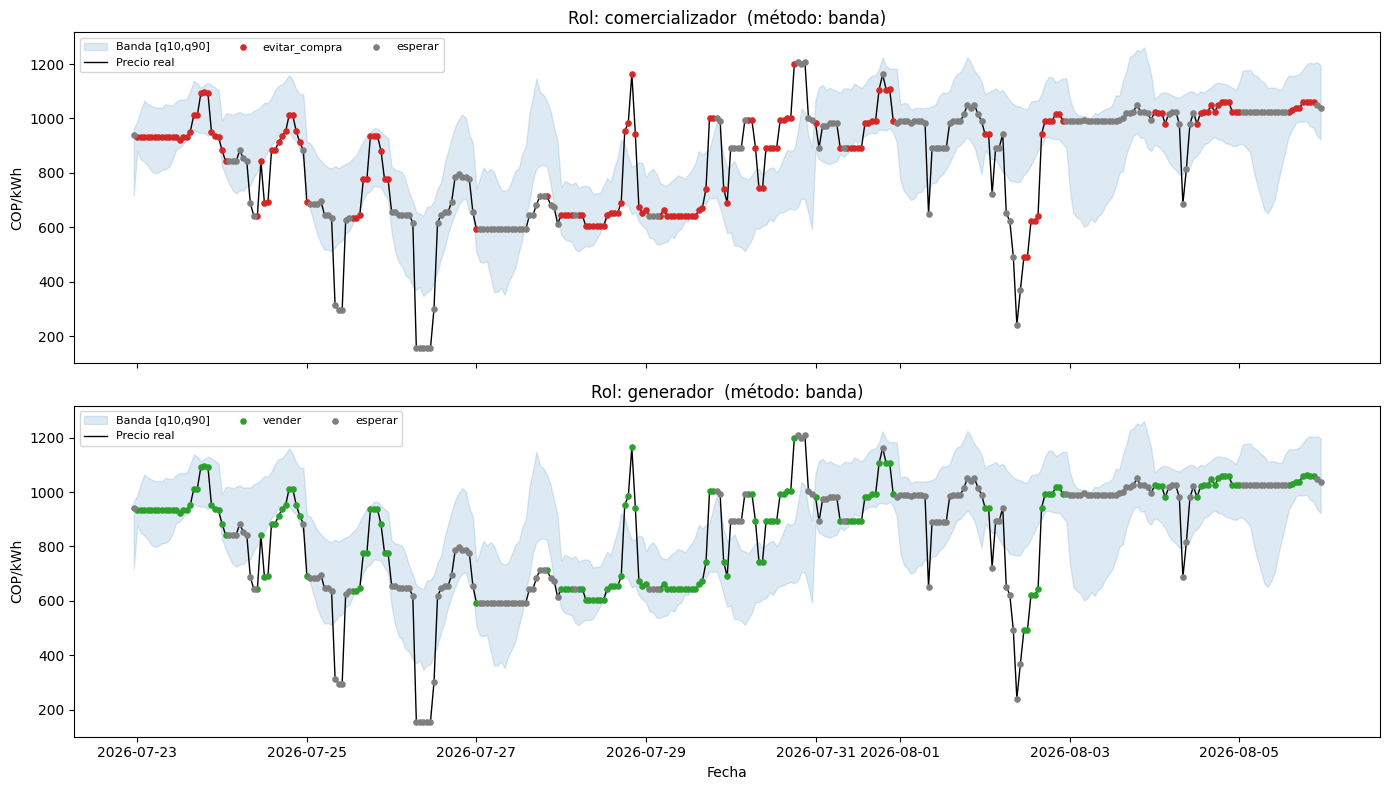

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colores = {
    "comprar": "tab:green", "evitar_compra": "tab:red",
    "vender": "tab:green", "retener": "tab:red",
    "esperar": "tab:gray",
}

for ax, rol in zip(axes, ["comercializador", "generador"]):
    df_rol = señales_finales[(señales_finales["horizonte"] == "24h") & (señales_finales["rol"] == rol)].copy()
    df_rol = df_rol[df_rol["fecha_hora"] >= df_rol["fecha_hora"].max() - pd.Timedelta(days=14)]

    ax.fill_between(df_rol["fecha_hora"], df_rol["q10"], df_rol["q90"], alpha=0.15, color="tab:blue", label="Banda [q10,q90]")
    ax.plot(df_rol["fecha_hora"], df_rol["real"], color="black", linewidth=1, label="Precio real")
    for senal_valor, color in colores.items():
        subset = df_rol[df_rol["senal"] == senal_valor]
        if len(subset):
            ax.scatter(subset["fecha_hora"], subset["real"], color=color, s=14, label=senal_valor, zorder=3)

    ax.set_title(f"Rol: {rol}  (método: {ganadores[('24h', rol)]})")
    ax.set_ylabel("COP/kWh")
    ax.legend(loc="upper left", fontsize=8, ncol=3)

plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

## Conclusiones y limitaciones

- El método ganador y su ventaja económica quedan en las celdas de arriba (varían según se ejecute
  con datos actualizados) -- ver salida de la sección 2.
- **Ambos horizontes usan ahora N-BEATSx con calibración conforme adaptativa** (cobertura ~78% en
  los dos). El fallback de XGBoost a 72h de la primera versión de este notebook ya no existe.
- El backtest de `evaluar_backtest()` es una comprobación mínima (precio promedio en horas de
  acción vs. promedio general), no una simulación de portafolio con restricciones operativas
  (capacidad de almacenamiento, contratos ya firmados, costos de transacción). Sirve para elegir
  entre los 3 métodos de umbral con evidencia, no como métrica de rentabilidad real del negocio.
- Pendiente natural: conectar esto con las métricas de decisión de `scripts_experimento/metricas_decision.py`
  (Corr-f/MHD/MPD) -- ahora mismo el motor solo usa el nivel de q50, no la forma completa del día.